# Evaluating Classification Models Using Precision and Recall

In [7]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

In [8]:
# Load Dataset

df = pd.read_csv('../data/raw/flood_data.csv')

print(df.head())

   rainfall  temperature  humidity  river_level  soil_moisture  flood_risk
0      23.5         18.2      45.0          1.2           0.35           0
1      34.2         22.1      52.0          1.8           0.42           0
2      45.6         25.3      65.0          2.5           0.48           1
3      28.3         20.5      48.0          1.5           0.38           0
4      52.1         28.1      72.0          3.2           0.55           1


In [9]:
# Select features and target

X = df[['rainfall', 'humidity', 'temperature']]

y = df['flood_risk']

In [10]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# Majority Class Baseline

baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [12]:
# Train logistic regression model

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [13]:
# Generate predictions

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]

In [14]:
# Precision and Recall Evaluation

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 3))

print("Recall:", round(recall, 3))

print("F1-score:", round(f1, 3))

Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [15]:
# Classification Report

print(classification_report(
    y_test,
    y_pred,
    digits=3
))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000         6
           1      1.000     1.000     1.000         5

    accuracy                          1.000        11
   macro avg      1.000     1.000     1.000        11
weighted avg      1.000     1.000     1.000        11



In [16]:
# Baseline Comparison

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print("=== Baseline ===")

print("Precision:", round(baseline_precision, 3))
print("Recall:", round(baseline_recall, 3))
print("F1-score:", round(baseline_f1, 3))

print("\n=== Logistic Regression ===")

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

=== Baseline ===
Precision: 0.0
Recall: 0.0
F1-score: 0.0

=== Logistic Regression ===
Precision: 1.0
Recall: 1.0
F1-score: 1.0


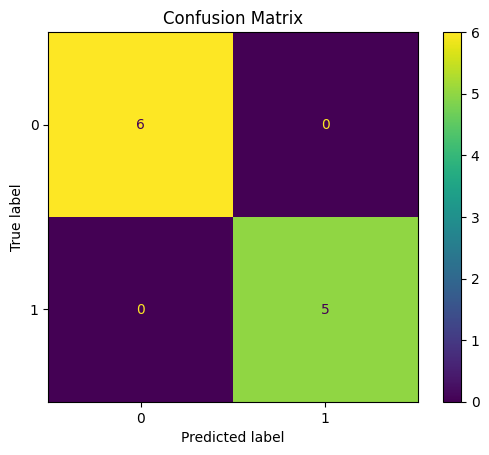

In [17]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [18]:
# Threshold Adjustment

threshold = 0.3

y_custom = (y_prob >= threshold).astype(int)

custom_precision = precision_score(
    y_test,
    y_custom
)

custom_recall = recall_score(
    y_test,
    y_custom
)

print(f"Threshold = {threshold}")

print("Precision:",
      round(custom_precision, 3))

print("Recall:",
      round(custom_recall, 3))

Threshold = 0.3
Precision: 1.0
Recall: 1.0


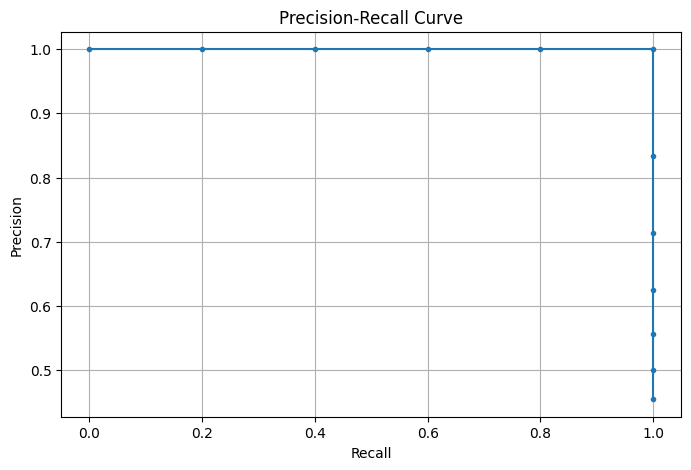

In [19]:
# Precision - Recall Curve

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    recalls,
    precisions,
    marker='.'
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [20]:
# Cross-Validation

cv_precision = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='precision'
)

cv_recall = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

cv_f1 = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("CV Precision:",
      round(cv_precision.mean(), 3),
      "±",
      round(cv_precision.std(), 3))

print("CV Recall:",
      round(cv_recall.mean(), 3),
      "±",
      round(cv_recall.std(), 3))

print("CV F1-score:",
      round(cv_f1.mean(), 3),
      "±",
      round(cv_f1.std(), 3))

CV Precision: 1.0 ± 0.0
CV Recall: 1.0 ± 0.0
CV F1-score: 1.0 ± 0.0


In [21]:
# Observations

print("Precision measures how reliable positive predictions are.")

print("Recall measures how many actual positive cases were detected.")

print("Lowering the threshold increased recall.")

print("Logistic Regression outperformed the baseline classifier.")

print("Precision and Recall should always be interpreted together.")

Precision measures how reliable positive predictions are.
Recall measures how many actual positive cases were detected.
Lowering the threshold increased recall.
Logistic Regression outperformed the baseline classifier.
Precision and Recall should always be interpreted together.
